In [1]:
# Test to load one pickle file
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

from lameg.laminar import compute_csd
from lameg.viz import plot_csd

In [3]:
filepath = '/home/sgailhard/Documents/laminar_meg/laminar_csd_method/simulations/2_double_dipole/1_simultaneous/_output/sim_2_simult_sources_snr'
filename = 'vx27692_2_simult_sources_snr-50.pickle'

with open(os.path.join(filepath, filename), 'rb') as f:
    data = pickle.load(f)

In [4]:
data

{'sim_vertex': 27692,
 'n_layers': 11,
 'sim_layers': [(0, 10), (1, 9), (2, 8), (3, 7), (4, 6)],
 'patch_size': 5,
 'err_level': 0,
 'sim_patch_size': 5,
 'n_temp_modes_ebb': 4,
 'n_spatial_modes': 'auto',
 'hann_windowing_ebb': False,
 'snr': -50,
 'dipole_moment': [10, 10],
 'sim_signal': array([[0.00907509, 0.011109  , 0.01353844, 0.01642602, 0.01984109,
         0.02385991, 0.0285655 , 0.03404745, 0.04040148, 0.04772871,
         0.05613476, 0.06572853, 0.07662063, 0.08892162, 0.10273981,
         0.11817892, 0.13533528, 0.15429501, 0.17513079, 0.1978987 ,
         0.22263487, 0.24935221, 0.2780373 , 0.30864746, 0.3411082 ,
         0.3753111 , 0.41111229, 0.44833156, 0.48675226, 0.52612196,
         0.56615415, 0.60653066, 0.64690518, 0.68690756, 0.72614904,
         0.76422817, 0.8007374 , 0.83527021, 0.86742847, 0.89683006,
         0.92311635, 0.94595947, 0.96506912, 0.98019867, 0.9911505 ,
         0.99778025, 1.        , 0.99778025, 0.9911505 , 0.98019867,
         0.96506912

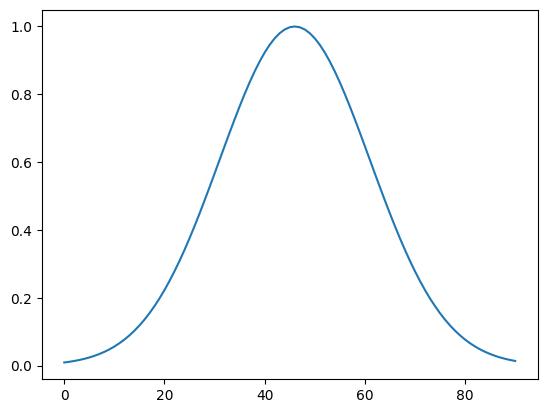

In [7]:
# plot the sim signal
plt.plot(data["sim_signal"][0])

In [8]:
data.keys()

dict_keys(['sim_vertex', 'n_layers', 'sim_layers', 'patch_size', 'err_level', 'sim_patch_size', 'n_temp_modes_ebb', 'n_spatial_modes', 'hann_windowing_ebb', 'snr', 'dipole_moment', 'sim_signal', 'win_size', 'woi', 'sfreq', 'thickness', 'time', 'ts_ebb', 'ts_ebb_layer', 'fs', 'fid_coords'])

In [9]:
n_layers = data["fs"].shape[1]

In [10]:
# get the relative free energy 
fs_matrix = data['fs']      # (n_rows, 11, 11)
relativeFs = np.array([
        fs_matrix[sim_idx, :] - fs_matrix[sim_idx, :].min()
        for sim_idx in range(fs_matrix.shape[0])
    ])

In [11]:
relativeFs.shape #(n_sim, n_layers)

(5, 11)

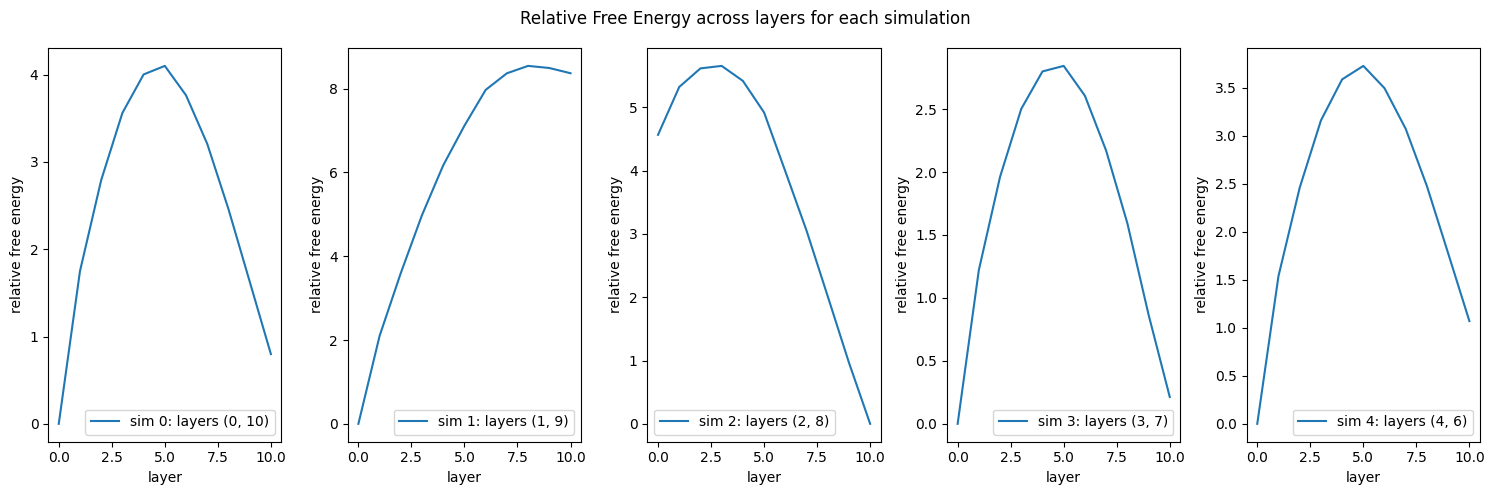

In [15]:
fig, ax = plt.subplots(1, relativeFs.shape[0], figsize=(15, 5))
for i in range(relativeFs.shape[0]):
    ax[i].plot(relativeFs[i, :], label=f'sim {i}: layers {data["sim_layers"][i]}')
    ax[i].set_xlabel('layer')
    ax[i].set_ylabel('relative free energy')
    ax[i].legend()
plt.suptitle('Relative Free Energy across layers for each simulation')
plt.tight_layout()
plt.show()

In [66]:
# get the ebb matrix
sfreq = data['sfreq']
thickness = data['thickness']
ebb_matrix = data['ts_ebb']      # (n_sim, n_layers)
csd_ebb = np.array([
        compute_csd(ebb_matrix[sim_idx, :], thickness, sfreq, Rs=np.array([1.5, 2]))
        for sim_idx in range(ebb_matrix.shape[0])
    ])

No lambda given, using defaults
Cross validating R (all lambda) : 1.5
Cross validating R (all lambda) : 2.0
R, lambda : 1.5 1.615598098439873e-07
No lambda given, using defaults
Cross validating R (all lambda) : 1.5
Cross validating R (all lambda) : 2.0
R, lambda : 2.0 1.9573417814876577e-09
No lambda given, using defaults
Cross validating R (all lambda) : 1.5
Cross validating R (all lambda) : 2.0
R, lambda : 2.0 2.1544346900318779e-10
No lambda given, using defaults
Cross validating R (all lambda) : 1.5
Cross validating R (all lambda) : 2.0
R, lambda : 2.0 1.9573417814876577e-09
No lambda given, using defaults
Cross validating R (all lambda) : 1.5
Cross validating R (all lambda) : 2.0
R, lambda : 2.0 1.9573417814876577e-09


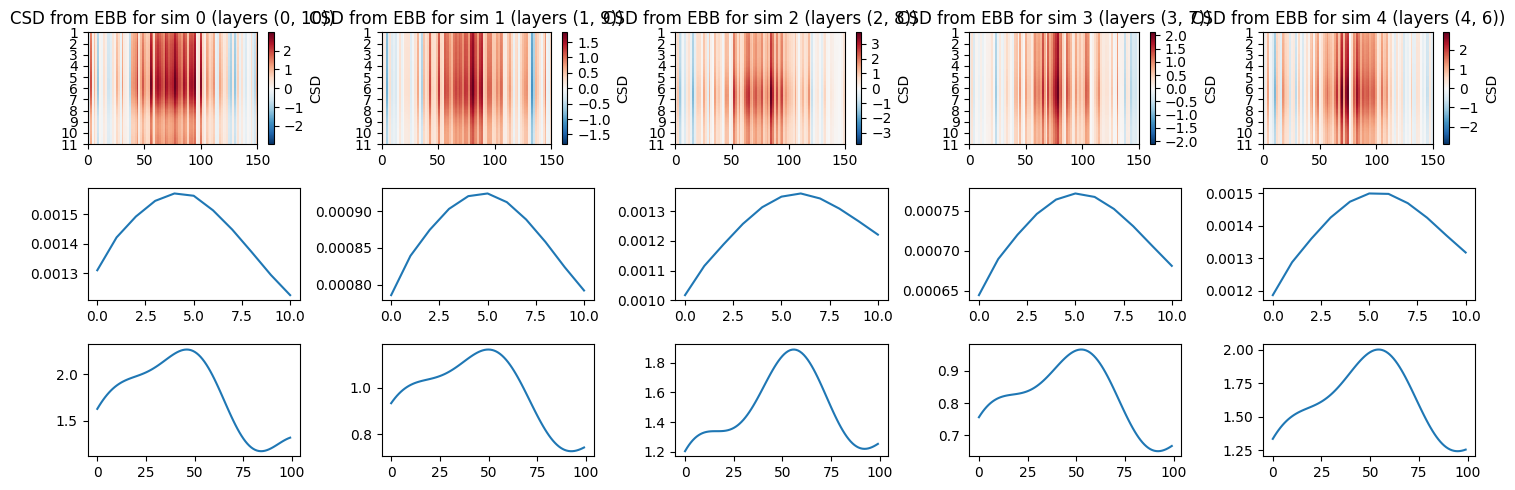

In [67]:
fig, ax = plt.subplots(3, csd_ebb.shape[0], figsize=(15, 5))
for sim_idx in range(csd_ebb.shape[0]):
    plot_csd(csd_ebb[sim_idx, :], data["time"], ax[0, sim_idx])  
    ax[0, sim_idx].set_title(f'CSD from EBB for sim {sim_idx} (layers {data["sim_layers"][sim_idx]})')
    ax[1, sim_idx].plot(np.mean(ebb_matrix[sim_idx, :, 40:45], axis=1))
    ax[2, sim_idx].plot(np.mean(csd_ebb[sim_idx, :, 40:45], axis=1))

In [75]:
# get the ebb_layer matrix
ebb_layer_matrix = data['ts_ebb_layer']      # (n_sim, n_layers)
csd_ebb_layer = np.array([
        compute_csd(ebb_layer_matrix[sim_idx, :], thickness, sfreq, Rs=np.array([0.8, 1.5, 1.7, 1.8, 2]))
        for sim_idx in range(ebb_layer_matrix.shape[0])
    ])

No lambda given, using defaults
Cross validating R (all lambda) : 0.8
Cross validating R (all lambda) : 1.5
Cross validating R (all lambda) : 1.7
Cross validating R (all lambda) : 1.8
Cross validating R (all lambda) : 2.0
R, lambda : 2.0 2.1544346900318779e-10
No lambda given, using defaults
Cross validating R (all lambda) : 0.8
Cross validating R (all lambda) : 1.5
Cross validating R (all lambda) : 1.7
Cross validating R (all lambda) : 1.8
Cross validating R (all lambda) : 2.0
R, lambda : 1.8 2.3713737056616552e-11
No lambda given, using defaults
Cross validating R (all lambda) : 0.8
Cross validating R (all lambda) : 1.5
Cross validating R (all lambda) : 1.7
Cross validating R (all lambda) : 1.8
Cross validating R (all lambda) : 2.0
R, lambda : 1.8 2.6101572156825332e-12
No lambda given, using defaults
Cross validating R (all lambda) : 0.8
Cross validating R (all lambda) : 1.5
Cross validating R (all lambda) : 1.7
Cross validating R (all lambda) : 1.8
Cross validating R (all lambda) :

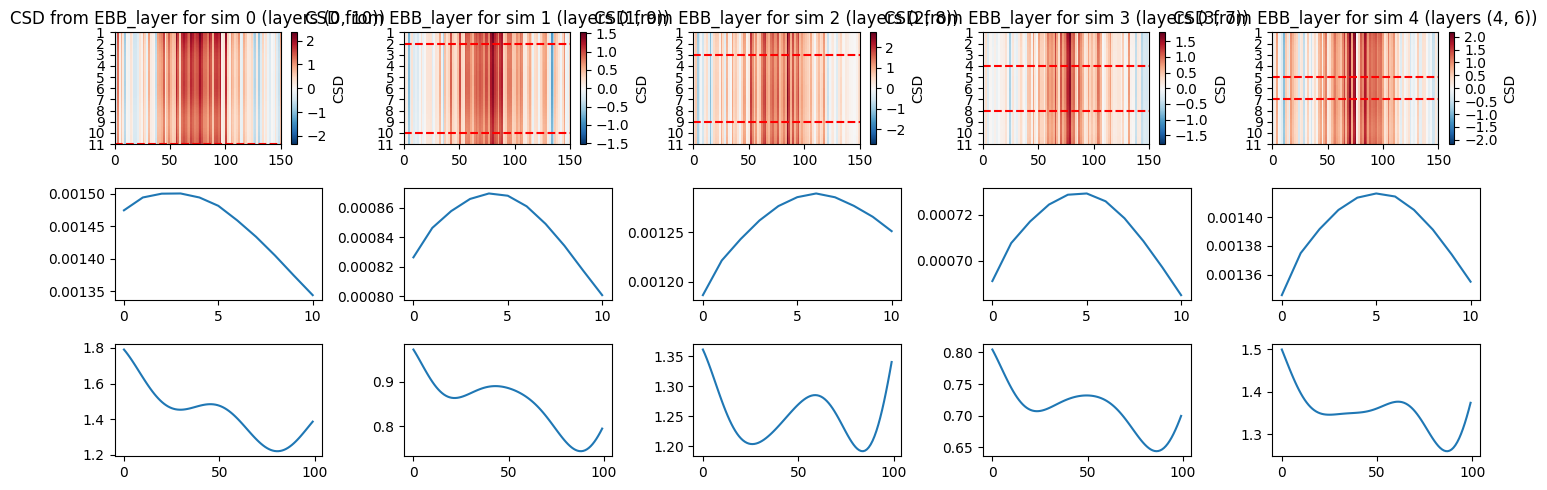

In [78]:
fig, ax = plt.subplots(3, csd_ebb_layer.shape[0], figsize=(15, 5))
for sim_idx in range(csd_ebb_layer.shape[0]):
    plot_csd(csd_ebb_layer[sim_idx, :], data["time"], ax[0, sim_idx])  
    ax[0, sim_idx].set_title(f'CSD from EBB_layer for sim {sim_idx} (layers {data["sim_layers"][sim_idx]})')
    for layer in data["sim_layers"][sim_idx]:
        ax[0,sim_idx].axhline(layer/(n_layers-1), color='red', linestyle='--')
    ax[1, sim_idx].plot(np.mean(ebb_layer_matrix[sim_idx, :, 40:45], axis=1))
    ax[2, sim_idx].plot(np.mean(csd_ebb_layer[sim_idx, :, 40:45], axis=1))